#### This notebook shows how to read the fastMRI dataset and apply some simple transformations to the data.

#### This notebook does not include the raw data files. In order to run the notebook, you need to download them from https://fastmri.med.nyu.edu/

In [2]:
%matplotlib inline

import h5py
import numpy as np
from matplotlib import pyplot as plt

The fastMRI dataset is distributed as a set of HDF5 files and can be read with the h5py package. Here, we show how to open a file from the multi-coil dataset. Each file corresponds to one MRI scan and contains the k-space data, ground truth and some meta data related to the scan.

In [4]:
file_name = 'singlecoil_train/file1000167.h5'
# file_name = 'singlecoil_test/file1000036.h5'
# file_name = 'reconstructions/file1000036.h5'
hf = h5py.File(file_name)

In [5]:
print('Keys:', list(hf.keys()))
print('Attrs:', dict(hf.attrs))

Keys: ['ismrmrd_header', 'kspace', 'reconstruction_esc', 'reconstruction_rss']
Attrs: {'acquisition': 'CORPDFS_FBK', 'max': 0.00020304603279609415, 'norm': 0.040851514300067004, 'patient_id': '85e5050fe8a675edc7a4e7a640355b99d39ad209e77f4f978326f842a0cef337'}


In multi-coil MRIs, k-space has the following shape:
(number of slices, number of coils, height, width)

For single-coil MRIs, k-space has the following shape:
(number of slices, height, width)

MRIs are acquired as 3D volumes, the first dimension is the number of 2D slices.

In [7]:
# volume_kspace = hf['reconstruction'][()]
volume_kspace = hf['kspace'][()]
print(volume_kspace.dtype)
print(volume_kspace.shape)

complex64
(30, 640, 372)


In [12]:
# slice_kspace = volume_kspace[20][0] # Choosing the 20-th slice of this volume
slice_kspace = volume_kspace[20] # Choosing the 20-th slice of this volume

Let's see what the absolute value of k-space looks like:

In [14]:
def show_coils(data, slice_nums, cmap=None):
    fig = plt.figure()
    for i, num in enumerate(slice_nums):
        plt.subplot(1, len(slice_nums), i + 1)
        plt.imshow(data[num], cmap=cmap)

In [16]:
def show_slice(slice_kspace):
    plt.figure()
    plt.imshow(slice_kspace, cmap='gray')
    plt.title("Single Coil k-space")
    plt.axis('off')
    plt.show()

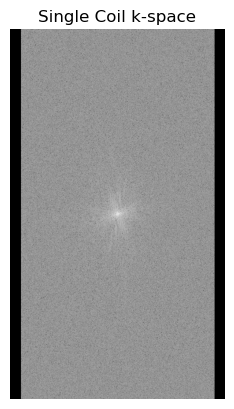

In [17]:
# show_coils(np.log(np.abs(slice_kspace) + 1e-9), [0, 5, 10])  # This shows coils 0, 5 and 10
show_slice(np.log(np.abs(slice_kspace) + 1e-9))

The fastMRI repo contains some utlity functions to convert k-space into image space. These functions work on PyTorch Tensors. The to_tensor function can convert Numpy arrays to PyTorch Tensors.

In [9]:
import torch
print(torch.__version__)  # Check the PyTorch version
print(torch.cuda.is_available())  # Should print False since there’s no CUDA support on Mac

2.5.1
False


In [20]:
import fastmri
from fastmri.data import transforms as T

In [ ]:
slice_kspace2 = T.to_tensor(slice_kspace)      # Convert from numpy array to pytorch tensor
slice_image = fastmri.ifft2c(slice_kspace2)           # Apply Inverse Fourier Transform to get the complex image
slice_image_abs = fastmri.complex_abs(slice_image)   # Compute absolute value to get a real image

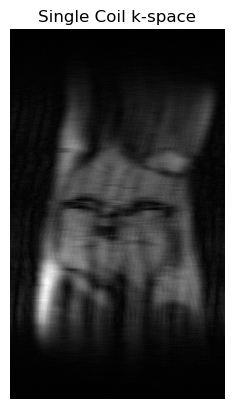

In [ ]:
# show_coils(slice_image_abs, [0, 5, 10], cmap='gray')
show_slice(slice_image_abs)

As we can see, each coil in a multi-coil MRI scan focusses on a different region of the image. These coils can be combined into the full image using the Root-Sum-of-Squares (RSS) transform.

In [ ]:
slice_image_rss = fastmri.rss(slice_image_abs, dim=0)

In [ ]:
plt.imshow(np.abs(slice_image_rss.numpy()), cmap='gray')

So far, we have been looking at fully-sampled data. We can simulate under-sampled data by creating a mask and applying it to k-space.

In [ ]:
from fastmri.data.subsample import RandomMaskFunc
mask_func = RandomMaskFunc(center_fractions=[0.04], accelerations=[8])  # Create the mask function object

In [ ]:
masked_kspace, mask, _ = T.apply_mask(slice_kspace2, mask_func)   # Apply the mask to k-space

Let's see what the subsampled image looks like:

In [ ]:
sampled_image = fastmri.ifft2c(masked_kspace)           # Apply Inverse Fourier Transform to get the complex image
sampled_image_abs = fastmri.complex_abs(sampled_image)   # Compute absolute value to get a real image
sampled_image_rss = fastmri.rss(sampled_image_abs, dim=0)

In [ ]:
plt.imshow(np.abs(sampled_image_rss.numpy()), cmap='gray')

In [ ]:
file_path = "/home/hice1/romeara6/scratch/fastMRI/singlecoil_test/file1000022.h5"

with h5py.File(file_path, "r") as f:
    # Assuming the dataset name is 'reconstruction'
    image = np.array(f["reconstruction"])  
    print(image.shape)
    print(image.dtype)

    # Display the first slice
    plt.imshow(image[0][0])
    plt.colorbar()
    plt.title("Reconstructed MRI")
    plt.show()

In [25]:
# Set dataset index to visualize
datasetInd = "1000000"

complex64
(35, 640, 368)
(640, 368)


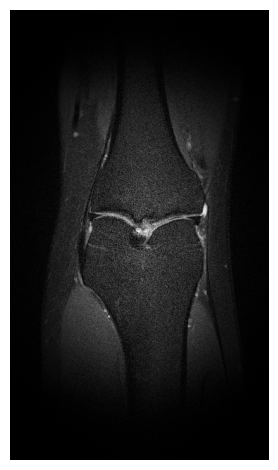

In [27]:
from scipy.ndimage import gaussian_filter

#VISUALIZE ORIGINAL K-SPACE
file_name = "singlecoil_val/file" + datasetInd + ".h5"
hf = h5py.File(file_name)

# print('Keys:', list(hf.keys()))
# print('Attrs:', dict(hf.attrs))

volume_kspace = hf['kspace'][()]
print(volume_kspace.dtype)
print(volume_kspace.shape)

slice_kspace = volume_kspace[20] # Choosing the 20-th slice of this volume

print(slice_kspace.shape)
#test: apply gaussian noise to k-space
slice_kspace = gaussian_filter(slice_kspace, sigma=0.75)

def show_coils(data, slice_nums, cmap=None):
    fig = plt.figure()
    for i, num in enumerate(slice_nums):
        plt.subplot(1, len(slice_nums), i + 1)
        plt.imshow(data[num], cmap=cmap)

def show_slice(slice_kspace):
    plt.figure()
    plt.imshow(slice_kspace, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

slice_kspace2 = T.to_tensor(slice_kspace)      # Convert from numpy array to pytorch tensor
slice_image = fastmri.ifft2c(slice_kspace2)           # Apply Inverse Fourier Transform to get the complex image
slice_image_abs = fastmri.complex_abs(slice_image)   # Compute absolute value to get a real image

# show_coils(slice_image_abs, [0, 5, 10], cmap='gray')
show_slice(slice_image_abs)

(34, 1, 320, 320)


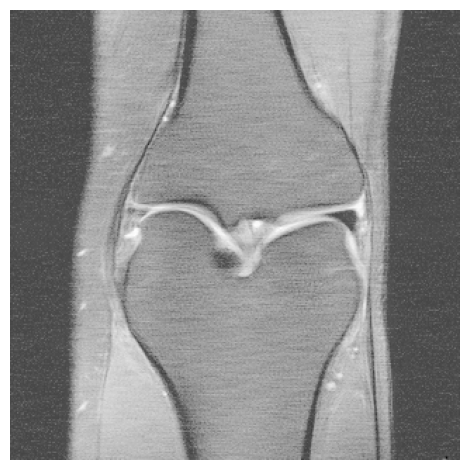

In [ ]:
#VISUALIZE RECONSTRUCTED IMAGE
file_name = "blurred.75/reconstructions/file" + datasetInd + ".h5"
hf = h5py.File(file_name)

# print('Keys:', list(hf.keys()))
# print('Attrs:', dict(hf.attrs))

volume_kspace = hf['reconstruction'][()]
# print(volume_kspace.dtype)
print(volume_kspace.shape)

slice_kspace = volume_kspace[20][0] # Choosing the 20-th slice of this volume

def show_coils(data, slice_nums, cmap=None):
    fig = plt.figure()
    for i, num in enumerate(slice_nums):
        plt.subplot(1, len(slice_nums), i + 1)
        plt.imshow(data[num], cmap=cmap)

def show_slice(slice_kspace):
    plt.figure()
    plt.imshow(slice_kspace, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_slice(np.log(np.abs(slice_kspace) + 1e-9))

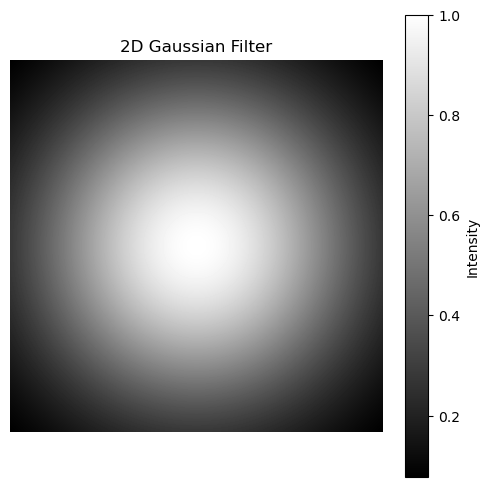

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define filter size and standard deviation
size = 320  # Size of the filter (100x100 pixels)
sigma = 100  # Standard deviation (controls blurriness)

# Create coordinate grid
x, y = np.meshgrid(np.linspace(-size//2, size//2, size), np.linspace(-size//2, size//2, size))

# Compute 2D Gaussian function
gaussian = np.exp(-(x**2 + y**2) / (2 * sigma**2))

# Normalize to range [0, 1]
gaussian /= gaussian.max()

# Plot the Gaussian filter
plt.figure(figsize=(6, 6))
plt.imshow(gaussian, cmap='gray')
plt.colorbar(label="Intensity")
plt.title("2D Gaussian Filter")
plt.axis("off")
plt.show()

# Print the filter as a matrix
# np.set_printoptions(precision=3, suppress=True)
# print(gaussian)
